<a href="https://colab.research.google.com/github/dev-yooillog/MAIN_QUEST/blob/main/Mini_Project/NYC_Taxi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 0. 필요한 라이브러리 import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import warnings
warnings.filterwarnings('ignore')

In [ ]:
use_cols = [
    'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count',
    'trip_distance', 'fare_amount', 'payment_type'
]

In [ ]:
path = '/content/drive/MyDrive/Colab Notebooks/yellow_tripdata_2025-*.parquet'
file_list = glob.glob(path)

In [ ]:
taxi_data = pd.concat([pd.read_parquet(f, columns=use_cols) for f in file_list], ignore_index=True)
raw_count = len(taxi_data)

### 데이터 정보 확인하기

In [ ]:
taxi_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12885358 entries, 0 to 12885357
Data columns (total 6 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   tpep_pickup_datetime   datetime64[us]
 1   tpep_dropoff_datetime  datetime64[us]
 2   passenger_count        float64       
 3   trip_distance          float64       
 4   fare_amount            float64       
 5   payment_type           int64         
dtypes: datetime64[us](2), float64(3), int64(1)
memory usage: 589.8 MB


### 결측치 및 중복 데이터 처리하기

In [ ]:
md = taxi_data.isna().sum()
md

,0
tpep_pickup_datetime,0
tpep_dropoff_datetime,0
passenger_count,3154852
trip_distance,0
fare_amount,0
payment_type,0


In [ ]:
md = (taxi_data.isna().mean() * 100)
md

,0
tpep_pickup_datetime,0.000000
tpep_dropoff_datetime,0.000000
passenger_count,24.484007
trip_distance,0.000000
fare_amount,0.000000
payment_type,0.000000


### 결측치 제거하기


In [ ]:
taxi_data = taxi_data.dropna(subset=['fare_amount'])
taxi_data.isna().sum()

,0
tpep_pickup_datetime,0
tpep_dropoff_datetime,0
passenger_count,3154852
trip_distance,0
fare_amount,0
payment_type,0


### 한줄로 표현 가능한 코드

In [ ]:
taxi_data['fare_amount'].isna().sum()

np.int64(0)

### 중복 데이터 처리하기

In [ ]:
taxi_data.duplicated().sum()

np.int64(1345)

In [ ]:
taxi_data = taxi_data.drop_duplicates()

In [ ]:
len(taxi_data)

12884013

데이터 타입 변환 및 시간 정보

In [ ]:
# 시간대 추출
taxi_data['pickup_hour'] = taxi_data['tpep_pickup_datetime'].dt.hour

In [ ]:
# 요일 추출
taxi_data['day_of_week'] = taxi_data['tpep_pickup_datetime'].dt.dayofweek

In [ ]:
taxi_data[['tpep_pickup_datetime', 'pickup_hour', 'day_of_week']].head()

,tpep_pickup_datetime,pickup_hour,day_of_week
0,2025-04-01 00:47:06,0,1
1,2025-04-01 00:27:35,0,1
2,2025-04-01 00:24:07,0,1
3,2025-04-01 00:56:30,0,1
4,2025-04-01 00:00:17,0,1


### 파생 변수 생성

In [ ]:
# 주행시간(duration) 계산
taxi_data['duration'] = (taxi_data['tpep_dropoff_datetime'] - taxi_data['tpep_pickup_datetime']).dt.total_seconds() / 60

In [ ]:
# 평균 주행 속도 계산
taxi_data['speed'] = taxi_data['trip_distance'] / (taxi_data['duration'] / 60)

In [ ]:
taxi_data[['tpep_pickup_datetime', 'duration', 'speed']].head()

,tpep_pickup_datetime,duration,speed
0,2025-04-01 00:47:06,26.316667,21.659278
1,2025-04-01 00:27:35,10.733333,21.074534
2,2025-04-01 00:24:07,11.083333,29.287218
3,2025-04-01 00:56:30,4.316667,8.339768
4,2025-04-01 00:00:17,16.033333,1.609148


### 이상치 탐지

In [ ]:
mask = (
    (taxi_data['trip_distance'] > 0) & (taxi_data['trip_distance'] < 30) &
    (taxi_data['fare_amount'] > 0) & (taxi_data['fare_amount'] <= 500) &
    (taxi_data['passenger_count'] >= 1) & (taxi_data['passenger_count'] <= 6) &
    (taxi_data['duration'] > 0) &
    (taxi_data['speed'] > 0) & (taxi_data['speed'] <= 65)
)
taxi_data = taxi_data[mask]
taxi_data

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,fare_amount,payment_type,pickup_hour,day_of_week,duration,speed,payment_type_label
0,2025-04-01 00:47:06,2025-04-01 01:13:25,1.0,9.50,38.7,1,0,1,26.316667,21.659278,Card
1,2025-04-01 00:27:35,2025-04-01 00:38:19,2.0,3.77,17.0,1,0,1,10.733333,21.074534,Card
2,2025-04-01 00:24:07,2025-04-01 00:35:12,1.0,5.41,22.6,1,0,1,11.083333,29.287218,Card
3,2025-04-01 00:56:30,2025-04-01 01:00:49,2.0,0.60,6.5,1,0,1,4.316667,8.339768,Card
4,2025-04-01 00:00:17,2025-04-01 00:16:19,1.0,0.43,4.4,2,0,1,16.033333,1.609148,Cash
...,...,...,...,...,...,...,...,...,...,...,...
11689177,2025-05-31 23:05:45,2025-05-31 23:26:55,1.0,1.89,18.4,1,23,5,21.166667,5.357480,Card
11689178,2025-05-31 23:32:52,2025-06-01 00:05:28,1.0,4.58,29.6,1,23,5,32.600000,8.429448,Card
11689179,2025-05-31 23:12:00,2025-05-31 23:20:03,1.0,1.61,10.0,1,23,5,8.050000,12.000000,Card
11689180,2025-05-31 23:26:32,2025-05-31 23:44:42,1.0,8.70,35.2,1,23,5,18.166667,28.733945,Card


### 데이터 표준화

In [ ]:
payment_map = {1: 'Card', 2: 'Cash', 3: 'No Charge', 4: 'Dispute', 5: 'Unknown', 6: 'Voided'}
taxi_data['payment_type_label'] = taxi_data['payment_type'].map(payment_map)

### 변수 간 상관관계

In [ ]:
print(taxi_data[['trip_distance', 'fare_amount', 'duration', 'speed']].corr())

               trip_distance  fare_amount  duration     speed
trip_distance       1.000000     0.932424  0.389329  0.677135
fare_amount         0.932424     1.000000  0.400781  0.578802
duration            0.389329     0.400781  1.000000  0.088010
speed               0.677135     0.578802  0.088010  1.000000


In [ ]:
cols = ['trip_distance', 'fare_amount', 'duration', 'speed']
corr_matrix = taxi_data[cols].corr()

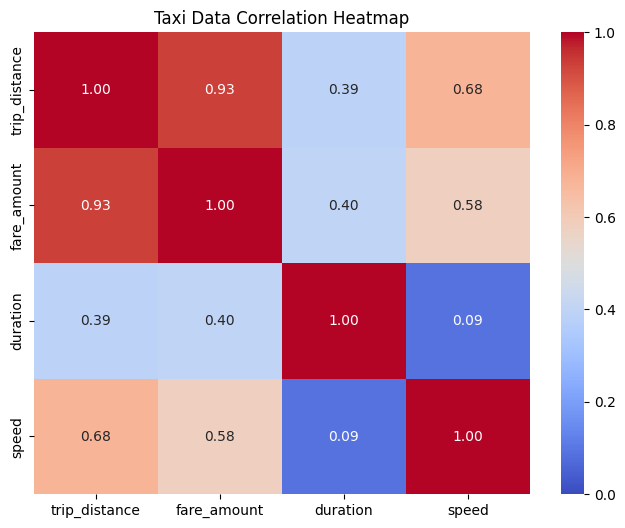

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix,
            annot=True,
            fmt=".2f",
            cmap='coolwarm',
            vmin=0, vmax=1)

plt.title("Taxi Data Correlation Heatmap")
plt.show()

### EDA

In [ ]:
# 요일 이름 매핑 (0=월, 6=일)
day_map = {0: 'Mon', 1: 'Tue', 2: 'Wed', 3: 'Thu', 4: 'Fri', 5: 'Sat', 6: 'Sun'}
taxi_data['day_name'] = taxi_data['day_of_week'].map(day_map)

In [ ]:
plt.figure(figsize=(12, 5))

<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

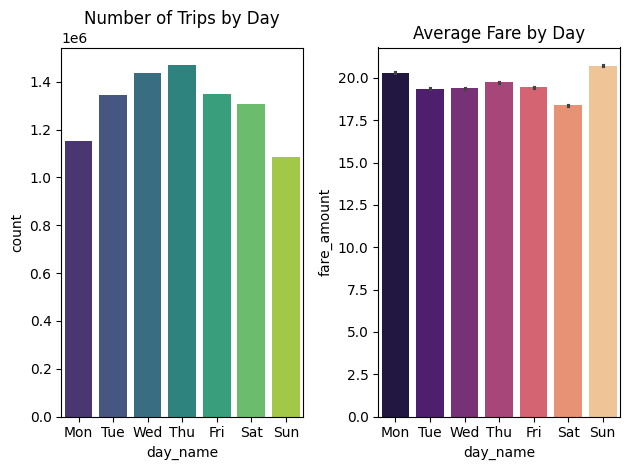

In [80]:
plt.subplot(1, 2, 1)
sns.countplot(data=taxi_data, x='day_name',
              order=['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'],
              palette='viridis')
plt.title("Number of Trips by Day")

plt.subplot(1, 2, 2)
sns.barplot(data=taxi_data, x='day_name', y='fare_amount',
            order=['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'],
            palette='magma')
plt.title("Average Fare by Day")
plt.tight_layout()
plt.show()

### 최종 저장

In [ ]:
taxi_data.to_csv('/content/drive/MyDrive/Colab Notebooks/cleaned_trip.csv', index=False)